In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for display settting to make more readable
pd.set_option('display.max_column', None) 
pd.set_option('display.float_format', '{:.2f}'.format) #tell panda to display number with 2 decimal place

#for visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6) 

In [3]:
bbca = pd.read_csv('BBCA.csv')
bbni = pd.read_csv('BBNI.csv')
bbri = pd.read_csv('BBRI.csv')
bmri = pd.read_csv('BMRI.csv')

In [4]:
bbca['Stock'] = 'BBCA'
bmri['Stock'] = 'BMRI'
bbni['Stock'] = 'BBNI'
bbri['Stock'] = 'BBRI'

In [5]:
#combine it all
df = pd.concat([bbca,bmri,bbri,bbni], ignore_index=True)

In [6]:
df.head()

,timestamp,open,low,high,close,volume,Stock
0,2001-04-16,175,175,180,177,0,BBCA
1,2001-04-17,175,175,180,177,0,BBCA
2,2001-04-18,175,175,180,177,0,BBCA
3,2001-04-19,175,175,180,177,0,BBCA
4,2001-04-20,175,175,180,177,0,BBCA


In [7]:
df.shape

(21425, 7)

In [8]:
df.describe()
#basic statistic: mean, std, min, max

,open,low,high,close,volume
count,21425.00,21425.00,21425.00,21425.00,21425.00
mean,3039.03,3002.94,3075.38,3038.46,77166802.28
std,2474.99,2445.11,2500.01,2473.96,114149014.93
min,97.00,95.00,100.00,97.00,0.00
25%,1090.00,1080.00,1113.00,1090.00,7942613.00
50%,2020.00,2000.00,2050.00,2020.00,47767500.00
75%,4800.00,4745.00,4850.00,4800.00,101785800.00
max,10875.00,10725.00,11000.00,10900.00,5144140000.00


In [9]:
df.head()

,timestamp,open,low,high,close,volume,Stock
0,2001-04-16,175,175,180,177,0,BBCA
1,2001-04-17,175,175,180,177,0,BBCA
2,2001-04-18,175,175,180,177,0,BBCA
3,2001-04-19,175,175,180,177,0,BBCA
4,2001-04-20,175,175,180,177,0,BBCA


In [10]:
df['Stock'].unique() #make sure everyting is load
df['Stock'].value_counts() #check the data total

Stock
BBCA    5670
BBNI    5670
BMRI    5085
BBRI    5000
Name: count, dtype: int64

In [11]:
missing_values = df.isnull().sum()
print(missing_values)

timestamp    0
open         0
low          0
high         0
close        0
volume       0
Stock        0
dtype: int64


In [12]:
duplicate = df.duplicated().sum()
print(duplicate)

0


In [13]:
df.dtypes

timestamp      str
open         int64
low          int64
high         int64
close        int64
volume       int64
Stock          str
dtype: object

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['Stock', 'timestamp'])
df = df.reset_index(drop=True)

In [15]:
df.dtypes

timestamp    datetime64[us]
open                  int64
low                   int64
high                  int64
close                 int64
volume                int64
Stock                   str
dtype: object

In [43]:
#Daily Return
df['Return'] = df.groupby('Stock')['close'].pct_change() #pct_change count the price different precentage

#Moving Average
df['MA_20'] = df.groupby('Stock')['close'].transform(lambda x: x.rolling(window=20).mean())
#lambda x is a quick function and x.rolling(window=20) is used to create moving windows of 20 rows
df['MA_200'] = df.groupby('Stock')['close'].transform(lambda x: x.rolling(window=200).mean())

#Volatility
TRADING_DAYS = 250

df['Volatility'] = df.groupby('Stock')['Return'].transform(
    lambda x: x.rolling(window=20).std() * np.sqrt(TRADING_DAYS)
)

#Cumulative return that measure how an investment grows over time.
df['Cumulative_Return'] = (1 + df['Return']).groupby(df['Stock']).cumprod()
#(1 + df['Return']) used to convert return into growth factors

In [31]:
df.head(5)

,timestamp,open,low,high,close,volume,Stock,Return,MA_20,MA_200,Volatility,Cumulative_Return
0,2001-04-16,175,175,180,177,0,BBCA,NaN,NaN,NaN,NaN,NaN
1,2001-04-17,175,175,180,177,0,BBCA,0.00,NaN,NaN,NaN,1.00
2,2001-04-18,175,175,180,177,0,BBCA,0.00,NaN,NaN,NaN,1.00
3,2001-04-19,175,175,180,177,0,BBCA,0.00,NaN,NaN,NaN,1.00
4,2001-04-20,175,175,180,177,0,BBCA,0.00,NaN,NaN,NaN,1.00


In [32]:
df.tail(5)

,timestamp,open,low,high,close,volume,Stock,Return,MA_20,MA_200,Volatility,Cumulative_Return
21420,2023-01-02,9925,9875,9975,9875,2992700,BMRI,-0.01,10036.25,8847.12,22.95,23.68
21421,2023-01-03,9850,9850,9975,9950,6907600,BMRI,0.01,9988.75,8857.25,23.23,23.86
21422,2023-01-04,10025,9975,10075,10025,19287900,BMRI,0.01,9971.25,8868.00,16.93,24.04
21423,2023-01-05,10050,9725,10050,9825,42472900,BMRI,-0.02,9960.00,8877.62,14.63,23.56
21424,2023-01-06,9725,9600,9800,9800,22048500,BMRI,-0.00,9953.75,8887.25,14.03,23.50


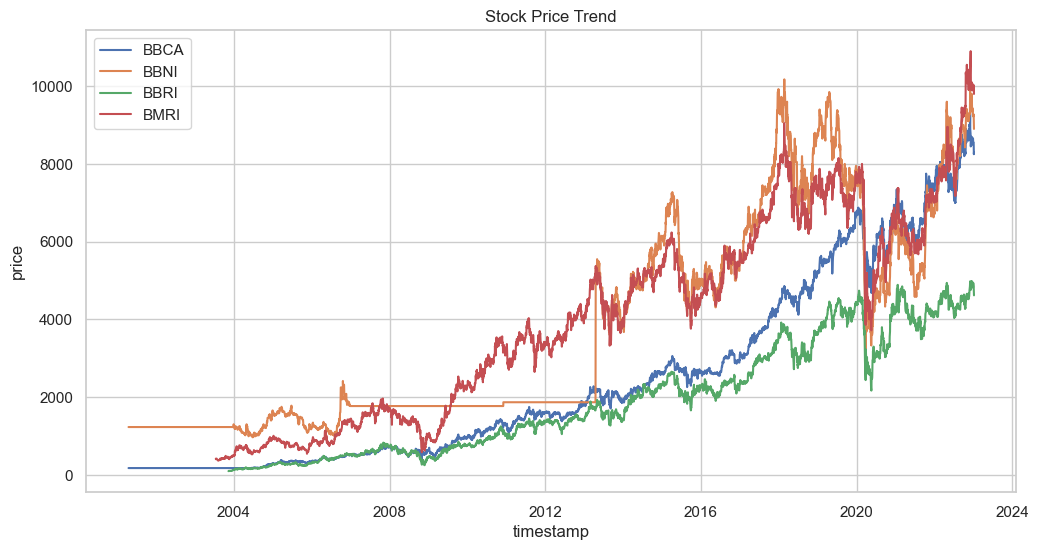

In [33]:
#price Trend
plt.figure()

for stock in df['Stock'].unique(): #get all stock name
    subset = df[df['Stock'] == stock] #take only rows for one stock
    plt.plot(subset['timestamp'], subset ['close'], label=stock) #x is timestamp and y is close as price

plt.title('Stock Price Trend')
plt.xlabel('timestamp')
plt.ylabel('price')
plt.legend()
plt.show()

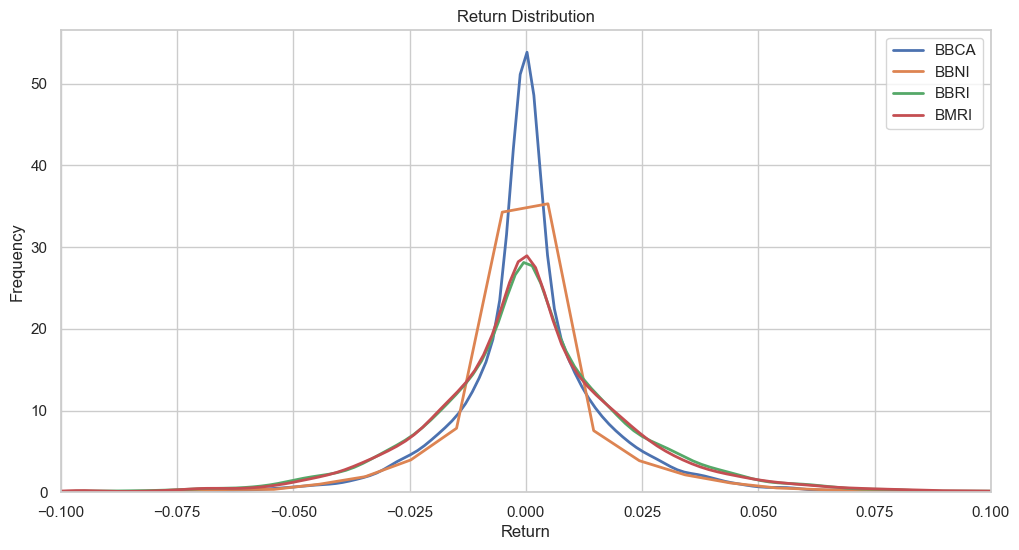

In [44]:
#Return Distribution
plt.figure()


for stock in df['Stock'].unique():
    subset = df[df['Stock'] == stock]
    sns.kdeplot(subset['Return'], label=stock, linewidth=2) 
    plt.xlim(-0.1, 0.1) #return beteween -10% to 10%
    

plt.title('Return Distribution')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()


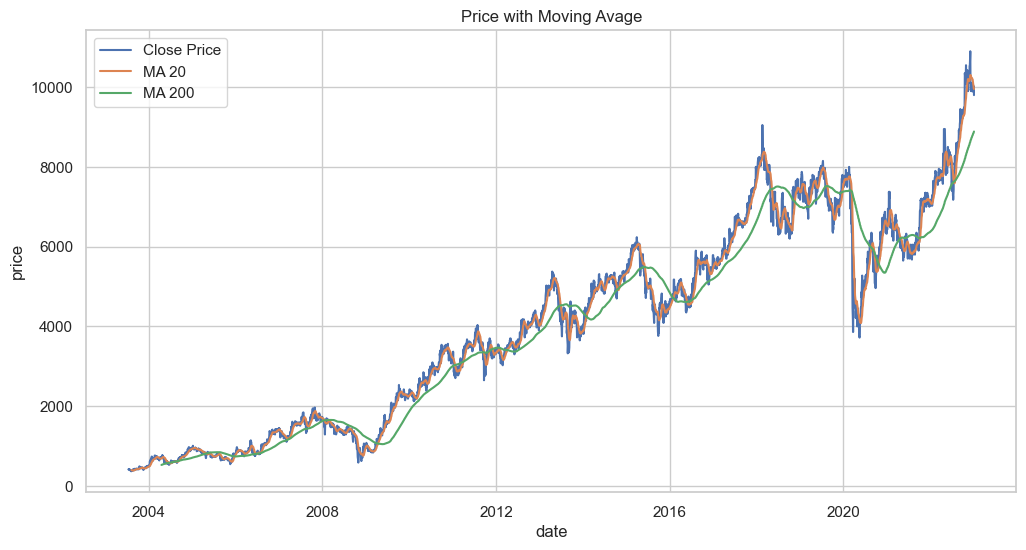

In [35]:
#Moving average
stock_example = 'BMRI'
subset = df[df['Stock'] == stock_example]

plt.figure()

plt.plot(subset['timestamp'], subset['close'], label='Close Price')
plt.plot(subset['timestamp'], subset['MA_20'], label='MA 20')
plt.plot(subset['timestamp'], subset['MA_200'], label='MA 200')

plt.title('Price with Moving Avage')
plt.xlabel('date')
plt.ylabel('price')
plt.legend()
plt.show()

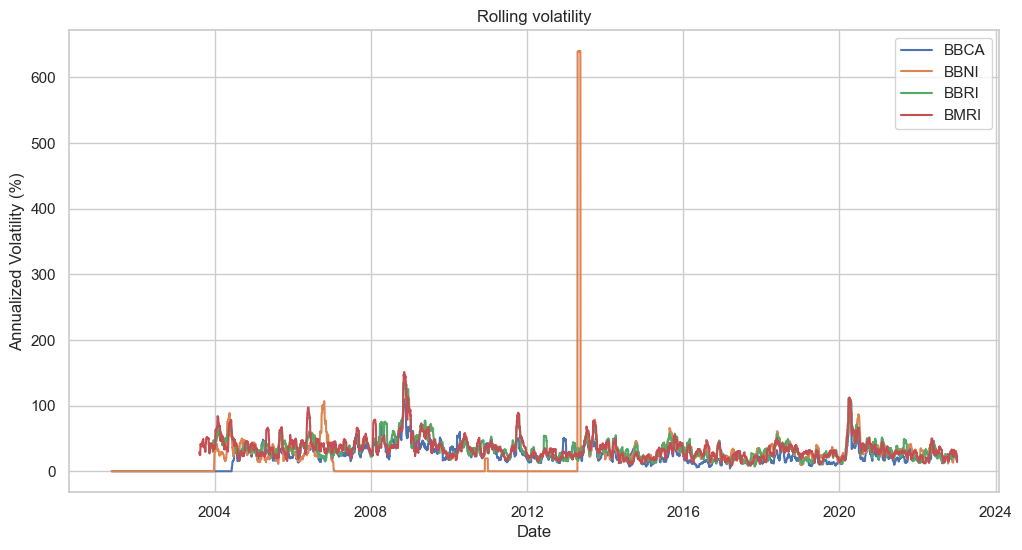

In [40]:
#Volatility
plt.figure()

for stock in df['Stock'].unique():
    subset = df[df['Stock'] == stock]
    plt.plot(subset['timestamp'], subset['Volatility'], label=stock)

plt.title('Rolling volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.show()

In [37]:
print(df.groupby('Stock')['Return'].describe())

        count  mean  std   min   25%  50%  75%  max
Stock                                              
BBCA  5669.00  0.00 0.02 -0.10 -0.01 0.00 0.01 0.17
BBNI  5669.00  0.00 0.03 -0.12  0.00 0.00 0.00 1.81
BBRI  4999.00  0.00 0.02 -0.13 -0.01 0.00 0.01 0.20
BMRI  5084.00  0.00 0.02 -0.15 -0.01 0.00 0.01 0.20


In [38]:
# Find the exact row where return = 1.81
bbni = df[df['Stock'] == 'BBNI'].sort_values('timestamp').reset_index(drop=True)
bad_idx = bbni['Return'].idxmax()

# Show the row after and before
bbni.iloc[bad_idx-1 : bad_idx+2][['timestamp', 'close', 'Return']]

,timestamp,close,Return
3131,2013-04-16,1870,0.00
3132,2013-04-17,5250,1.81
3133,2013-04-18,5250,0.00


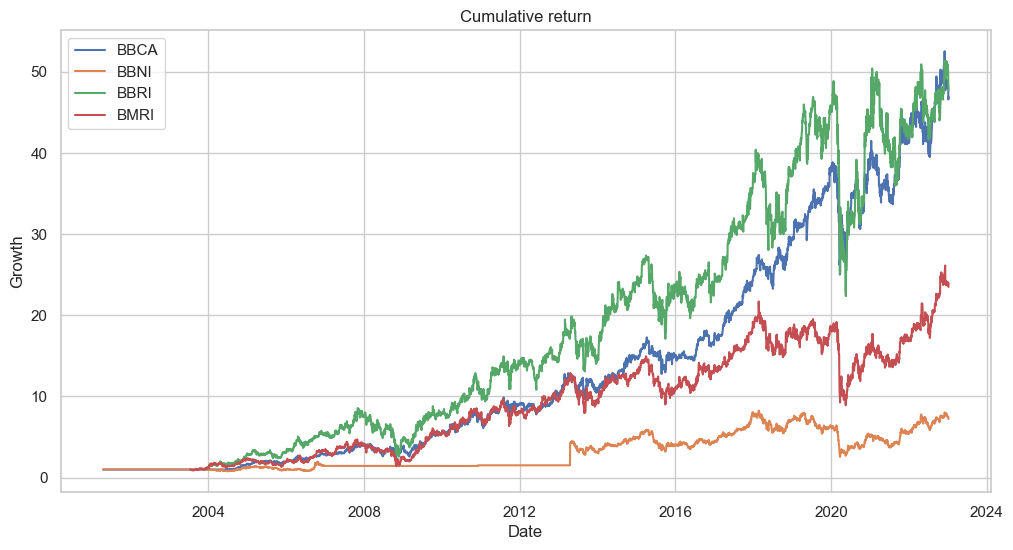

In [39]:
#Cumulative return
plt.figure()

for stock in df['Stock'].unique():
    subset = df[df['Stock'] == stock]
    plt.plot(subset['timestamp'], subset['Cumulative_Return'], label=stock)

plt.title('Cumulative return')
plt.xlabel('Date')
plt.ylabel('Growth')
plt.legend()
plt.show()